## Prelab 08 - Maximum Likelihood Estimation

### Exercise 8.1: Amplitude Estimation with Known Training Sequence


Consider a modulated system in which the samples at the receive filter output are given by
$$Y[k] = \theta s[k] + N[k], k = 1,2,..., K,$$
where $\theta$ is an unknown amplitude, $s[k]$ are transmitted symbols taking values $\pm 1$, and $N[k]$ are independent and identically distributed (IID) $N(0,\sigma^2)$ noise samples. We wish to find a maximum likelihood (ML) estimate for the amplitude $\theta$, using the vector observation $\mathbf{Y} = (Y[1],..., Y[K])^T$.  Assume that the transmitted symbols $s[k] \in \{-1, 1\}$ are known training symbols. Show that 

$$\hat{\theta}_{ML} = \frac{1}{K} \sum_{k = 1}^K Y[k]s[k]$$

Hints:

• Review Lecture 26 for an expression of the probability distribution pertaining to this exercise.

• Please note that as mentioned in Lecture 26, taking the natural logarithm of the maximum likelihood estimate helps simplify its expression. Remember also that the logarithm of a product is the sum of the logarithm of its factors.

• Please note that $\mathrm{arg max}_\theta \,x(\theta) - A = \mathrm{arg max}_\theta \, x(\theta)$ if $A$ is known.



*ANSWER:*

TODO

### Exercise 8.2: Estimation of the Standard Deviation of a Gaussian Distribution

Suppose $\mathbf{X} = (X[1],..., X[K])^T$ is a vector of independent and identically distributed random (IID) variables with density function 

$f(x; \sigma) = \frac{1}{\sqrt{2\pi \sigma^2}}e^{\frac{-(x - \mu)^2}{2\sigma^2}}$. Assume $\mu$ is known, and determine the maximum likelihood (ML) estimate of $\sigma$, the standard deviation of the distribution.

*ANSWER:*

TODO

### Exercise 8.3: Maximum Likelihood Simulation

Suppose the received samples are given by

$$
Y[k] = S + N[k], \qquad k=1,2,\dots,N,
$$

where  $ S $  is a one-bit signal that can take the values $ 0 $ or $ 1 $, and $ N[k] $ is a sequence of independent and identically distributed (IID) Gaussian random variables with mean $ ( 0  ) $ and variance $ ( \sigma^2 ) $, i.e.,

$$
N[k] \sim \mathcal{N}(0,\sigma^2).
$$

Your objective is to create an algorithm that determines whether $ S=1 $ was sent or  $ S=0 $ was sent.

For a candidate value \(s\), the log-likelihood function is

$$
l(s)=\ln\!\left(\prod_{k=1}^{N} f(Y[k]\mid s)\right)
= \sum_{k=1}^{N} \ln\big(f(Y[k]\mid s)\big),
$$

where  $ f (Y[k]\mid s) $ is the Gaussian density of  $ Y[k] $ conditioned on $ s $.

In the actual detection problem, the only valid hypotheses are  $ s=0 $ and  $ s=1 $. However, for visualization, you will evaluate  $ l(s) $ over a grid of values from  $ 0 $ to  $ 1 $.



#### Question 8.3a:

- Write a Python code that plots the log-likelihood $ l(s) $ as a function of  $ s $ when  $ \sigma=3 $.
- Use an array of candidate values of  $ s $ ranging from 0 to 1 in steps of 0.01.
- Add a line of code that prints the most likely value  $ s_p $, i.e., the value of  $ s $ for which  $ l(s) $ is the highest.
- Let  $ N $, the number of samples, be equal to 20.
- Use `np.random.normal` to generate the noise samples  $ N[k] $.
- Set  $ S=1 $ at the beginning of your code.

Hint:

You can simplify the likelihood expression by using the fact that the logarithm of a product is the sum of the logarithms.

Most likely value of s: 
1.0



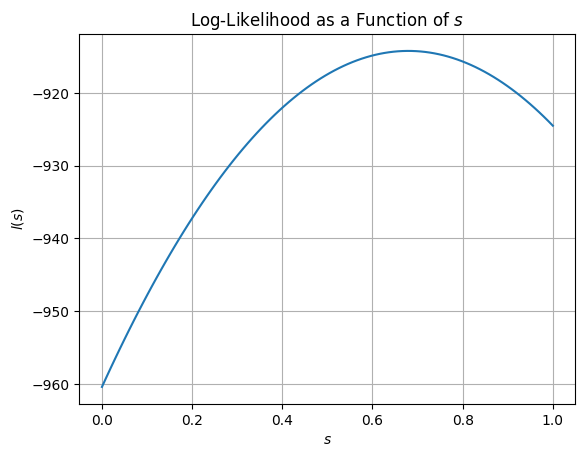

In [66]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)   # For reproducibility

sigma = 3         # Standard deviation
N = 20              # Number of samples
S = 0.5# True transmitted signal

# Generate the noise samples
noise = np.random.normal(loc = 0, scale = sigma, size=100)

# Form the received samples
Y = [(S + n) for n in noise]

# Candidate values of s from 0 to 1
s_array = np.linspace(0, 1, 100)

# Placeholder for the log-likelihood values
L = np.zeros(100)

# Compute the log-likelihood for each candidate value of s
for i in range(len(s_array)):
    s_test = s_array[i]
    
    # Fill in the log-likelihood expression here
    L[i] = -np.sum((s_test - Y)**2)

# Find the index of the maximum log-likelihood
idx_maxL = np.argmax(L)

print('Most likely value of s: ')
print(f'{np.round(s_array[idx_maxL])}\n')

# Plot the log-likelihood curve
plt.plot(s_array, L)
plt.title('Log-Likelihood as a Function of $s$')
plt.xlabel('$s$')
plt.ylabel('$l(s)$')
plt.grid(True)
plt.show()

#### Question 8.3b

Increase your standard deviation to $\sigma = 4$ , and run your code again. Increase it again to $\sigma=5$ and observe the result. What is the minimum standard deviation for which your algorithm starts deciding that the received signal is $0$ instead of $1$?

*ANSWER:*

The algoritm never decides that the signal is 0 instead of one, likely due to the fact that we seed the randomness the same every time. If I remove the random seed, it seems to begin deciding on 0 consistently around $\sigma = 10$, but this is subjective


### Exercise 8.4: Estimating the standard deviation of a AWGN noise

#### Question 8.4a:
In this exercise, you will create a code that confirms your equation for the estimate of $\sigma$ in Exercise 8.2. The signal of interest in ex. 8.2. was an additive white gaussian noise, or AWGN noise. There you came up with a way of estimating the standard deviation $\sigma$ of such a distribution. Create a normally distributed random variable of size 100 with a mean of 1 and $\sigma = 4$ using np.random.normal() and use your equation from Ex. 8.2 to print an estimate of $\sigma$.

In [27]:
import numpy as np

mu = 1
sig = 4

samples = 100000

X = np.random.normal(loc = mu, scale = sig, size = samples)

sig_estimate = np.sqrt((1/samples)*np.sum((X - mu)**2))

print(f'estimated sigma: {sig_estimate}')

estimated sigma: 4.002070359574586


### Question 8.4b:

Increase $N$ in the code above. What is the minimal value of N for which the error between the actual $\sigma$ (i.e. 4) and your estimate is reliably less than 0.01?

*ANSWER:*

increasing N to around 100000 results in an estimate that is consitently within 0.01

### Exercise 8.5: Matched filter responses

In Lab 08, you will implement a filter, called a matched filter, in the discrete-time domain for signal detection. For the sake of clarity, we will refer to the signal to be detected as the "desired signal". Ideally, the output of a  matched filter is small unless its input is the desired signal, in which case the filter produces a peak. In practice, the output of a matched filter is non-zero but exhibits one main peak. The peak value of the output of such a filter is used to determine the instant of detection (if the filter is implemented in the continuous-time domain) or the index of the first detected sample (if the filter is implemented in the discrete-time domain).

Let us first recall that all discrete-time linear time-invariant (LTI) filters can be mathematically described with one equation:

$$y[n] = \sum_{k} h[k] x[n-k],$$

where $h[n]$ denotes the impulse response of the filter. If $s[n]$ denotes the signal of interest, and the input to the filter is $x[n]=s[n-l]$ for some time-delay $l$, then the filter matched to $s[n]$ has impulse response $h[k]=s[-n]$, the time-reversed version of the signal of interest.

In this exercise, you will study the output of matched filters for various signals of interest. 
More specifically, you will create a vector $x[n]$ that represents the input signal of the matched filter. It will contain a pulse (a rectangular pulse in question 8.5a and a sinusoidal pulse in question 8.5b). Then you will create $h$ by time-reversing the pulse and then computing and observing $y[n]$. 


#### Question 8.5a

In this question, your pulse will be an array of ones. When computing y, please make sure of the following: 

• You will need to write two for loops, one nested in the other as the equation for $y[n]$ contains a summation.

• $y[n]$ will be twice as long as $x[n]$ (this is to capture the full output of the matched filter, even after the peak has occurred).

• Therefore, inside the second for loop, you will need two conditions (on $n-k$) to make sure that no out of bounds error will be raised. (Please use the instruction "continue" to skip an iteration of the second loop).

Index of detection
3


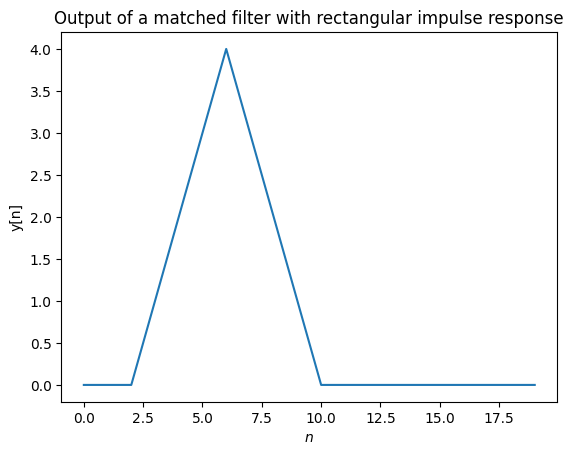

In [28]:
#| eval: false
import numpy as np
import matplotlib.pyplot as plt

width_of_rectangular_pulse = 4
size_of_array = 10
waveform_index = 3

# Create an array of zeros of size size_of_array
array_of_zeros =  np.zeros(size_of_array)

# Create an array of ones of size width_of_rectangular_pulse (this is the desired signal)
array_of_ones = np.full(width_of_rectangular_pulse, 1)

# Creating x by inserting the array of ones in the array of zeros at index waveform_index
array_of_zeros[waveform_index:waveform_index+width_of_rectangular_pulse] = array_of_ones
x = array_of_zeros

# Create the vector h (please pay attention on what function to use here). Hint: its size is width_of_rectangular_pulse
h = array_of_ones[::-1] #reverse

# Create an array of zeros of length 2*size_of_array for the output of the matched filter
y = np.zeros(2*size_of_array)

# Fill y by computing the discrete time convolution of h and x
for n in range(0,2*size_of_array):
    sum = 0
    for k in range(0,width_of_rectangular_pulse):
        if (n-k)<0 or n-k>=size_of_array:
            continue
        else:
            sum += h[k] * x[n-k]
    y[n] = sum

# Plotting and findinx the index waveform_index
plt.plot(y)
plt.title('Output of a matched filter with rectangular impulse response');
plt.xlabel('$n$');
plt.ylabel('y[n]');

max_y = np.max(y);
idx_max_y = np.where(y==max_y)[0][0]
print('Index of detection');
print(idx_max_y - width_of_rectangular_pulse + 1);

#### Question 8.5b

Repeat question 8.5a but use a sinusoidal pulse instead of all ones. Experiment with at least 3 different (normalized) frequencies of the sinusoid.

Index of detection
250


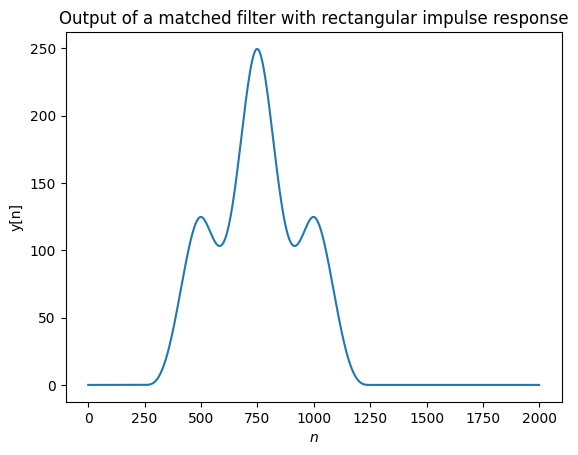

In [40]:
#| eval: false
import numpy as np
import matplotlib.pyplot as plt

width_of_sin = 500
size_of_array = 1000
waveform_index = 250

# Create an array of zeros of size size_of_array
array_of_zeros =  np.zeros(size_of_array)

# Create a sinusoidal pulse (one period)
s = np.linspace(0, 2*np.pi, width_of_sin)
sin_pulse = np.sin(s)

# Creating x by inserting the array of ones in the array of zeros at index waveform_index
array_of_zeros[waveform_index:waveform_index+width_of_sin] = sin_pulse
x = array_of_zeros

# Create the vector h (please pay attention on what function to use here). Hint: its size is width_of_rectangular_pulse
h = sin_pulse[::-1] #reverse

# Create an array of zeros of length 2*size_of_array for the output of the matched filter
y = np.zeros(2*size_of_array)

# Fill y by computing the discrete time convolution of h and x
for n in range(0,2*size_of_array):
    sum = 0
    for k in range(0,width_of_sin):
        if (n-k)<0 or n-k>=size_of_array:
            continue
        else:
            sum += abs(h[k] * x[n-k])
    y[n] = sum

# Plotting and findinx the index waveform_index
plt.plot(y)
plt.title('Output of a matched filter with rectangular impulse response');
plt.xlabel('$n$');
plt.ylabel('y[n]');

max_y = np.max(y);
idx_max_y = np.where(y==max_y)[0][0]
print('Index of detection');
print(idx_max_y - width_of_sin + 1);
